In [ ]:
# Student Roll No: 24BAD407

# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models


# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)


I0000 00:00:1791202194.968096    9357 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791202194.973660    9357 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791202195.401454    9357 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791202196.839339    9357 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

# PART A: DATASET PREPARATION AND IMAGE PREPROCESSING

In this part, the MNIST handwritten digit dataset is loaded, explored, normalized to the range **[-1, 1]**, reshaped, and converted into a TensorFlow data pipeline for batch-wise GAN training.


In [ ]:
# Student Roll No: 24BAD407
# PART A - Load and explore the MNIST dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images shape :", x_train.shape)
print("Training labels shape :", y_train.shape)
print("Testing images shape  :", x_test.shape)
print("Testing labels shape  :", y_test.shape)

print("\nNumber of training images:", len(x_train))
print("Image dimensions:", x_train.shape[1], "x", x_train.shape[2])
print("Pixel range before normalization:", x_train.min(), "to", x_train.max())


Training images shape : (60000, 28, 28)
Training labels shape : (60000,)
Testing images shape  : (10000, 28, 28)
Testing labels shape  : (10000,)

Number of training images: 60000
Image dimensions: 28 x 28
Pixel range before normalization: 0 to 255


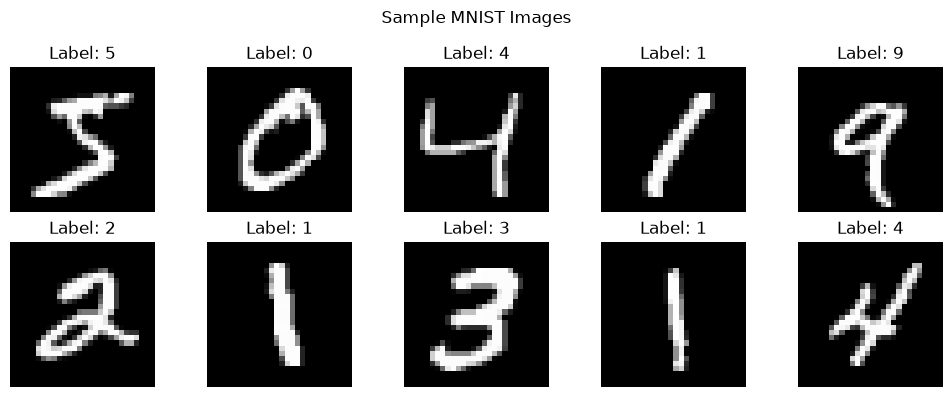

In [ ]:
# Student Roll No: 24BAD407
# Display sample images from the dataset

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()


In [ ]:
# Student Roll No: 24BAD407
# Normalize pixel values to [-1, 1] and reshape

x_train = x_train.astype("float32")

# Convert [0, 255] -> [-1, 1]
x_train = (x_train - 127.5) / 127.5

# Add channel dimension: (60000, 28, 28) -> (60000, 28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)

print("Shape after reshaping:", x_train.shape)
print("Pixel range after normalization:", x_train.min(), "to", x_train.max())


Shape after reshaping: (60000, 28, 28, 1)
Pixel range after normalization: -1.0 to 1.0


In [ ]:
# Student Roll No: 24BAD407
# Create TensorFlow input pipeline

BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(x_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print(train_dataset)

# Inspect one batch
for image_batch in train_dataset.take(1):
    print("Batch shape:", image_batch.shape)


<_PrefetchDataset element_spec=TensorSpec(shape=(256, 28, 28, 1), dtype=tf.float32, name=None)>
Batch shape: (256, 28, 28, 1)


E0000 00:00:1791202199.057625    9357 cuda_executor.cc:1690] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
=== Source Location Trace: === 
external/xla/xla/stream_executor/cuda/cuda_status.cc:68

W0000 00:00:1791202199.058414    9566 cuda_executor.cc:1710] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
=== Source Location Trace: === 
external/xla/xla/stream_executor/cuda/cudnn_api_wrappers.cc:77
external/xla/xla/stream_executor/cuda/cudnn_api_wrappers.cc:107
external/xla/xla/stream_executor/cuda/cudnn_api_wrappers.cc:112

W0000 00:00:1791202199.078509    9357 dlopen_checker.cc:38] Could not load dynamic library 'libcudart.so.12'; dlerror: libcudart.so.12: cannot open shared object file: No such file or directory
W0000 00:00:1791202199.078525    9

## PART A - Observation
- MNIST contains **60,000 training images** and **10,000 testing images**.
- Each image has dimensions **28 × 28 pixels**.
- A channel dimension is added so the GAN receives images in the shape **28 × 28 × 1**.
- Pixel values are normalized from **[0, 255]** to **[-1, 1]**, which matches the Generator's final `tanh` activation.


# PART B: IMPLEMENTING THE GENERATOR

The Generator converts a random noise vector into a synthetic 28 × 28 grayscale image. It uses a Dense layer followed by transposed convolution layers for upsampling.


In [ ]:
# Student Roll No: 24BAD407
# PART B - Define Generator

NOISE_DIM = 100

def build_generator():
    model = models.Sequential(name="Generator")

    model.add(layers.Input(shape=(NOISE_DIM,)))

    # Project and reshape noise vector
    model.add(layers.Dense(7 * 7 * 256, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))

    # 7x7 -> 7x7
    model.add(layers.Conv2DTranspose(
        128, kernel_size=5, strides=1, padding="same", use_bias=False
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 7x7 -> 14x14
    model.add(layers.Conv2DTranspose(
        64, kernel_size=5, strides=2, padding="same", use_bias=False
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 14x14 -> 28x28
    model.add(layers.Conv2DTranspose(
        1, kernel_size=5, strides=2, padding="same",
        use_bias=False, activation="tanh"
    ))

    return model

generator = build_generator()
generator.summary()


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

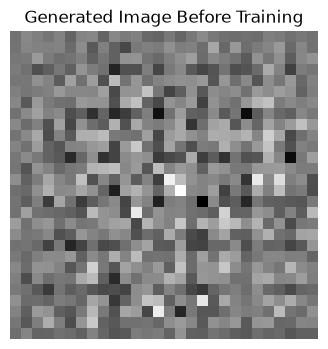

Generated image shape: (1, 28, 28, 1)


In [ ]:
# Student Roll No: 24BAD407
# Generate an image BEFORE GAN training

random_noise = tf.random.normal([1, NOISE_DIM])
generated_image = generator(random_noise, training=False)

plt.figure(figsize=(4, 4))
plt.imshow(generated_image[0, :, :, 0], cmap="gray")
plt.title("Generated Image Before Training")
plt.axis("off")
plt.show()

print("Generated image shape:", generated_image.shape)


## PART B - Observation
Before training, the Generator produces a noisy and unrecognizable image because its weights are randomly initialized. During adversarial training, these weights are gradually updated so the generated images resemble real handwritten digits.


# PART C: IMPLEMENTING THE DISCRIMINATOR AND GAN MODEL

The Discriminator acts as a binary classifier. It receives a 28 × 28 image and predicts whether the image is **real** or **generated (fake)**.

Binary cross-entropy is used because the task has two classes:
- Real image → 1
- Fake image → 0


In [ ]:
# Student Roll No: 24BAD407
# PART C - Define Discriminator

def build_discriminator():
    model = models.Sequential(name="Discriminator")

    model.add(layers.Input(shape=(28, 28, 1)))

    model.add(layers.Conv2D(
        64, kernel_size=5, strides=2, padding="same"
    ))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(
        128, kernel_size=5, strides=2, padding="same"
    ))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())

    # Logit output for binary classification
    model.add(layers.Dense(1))

    return model

discriminator = build_discriminator()
discriminator.summary()


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Student Roll No: 24BAD407
# Test Discriminator on an untrained generated image

decision = discriminator(generated_image, training=False)

print("Raw discriminator output (logit):", decision.numpy())
print("Probability of being real:", tf.sigmoid(decision).numpy())


Raw discriminator output (logit): [[0.0044812]]
Probability of being real: [[0.50112027]]


In [ ]:
# Student Roll No: 24BAD407
# Define loss functions and optimizers

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4,
    beta_1=0.5
)

print("Loss function: Binary Cross-Entropy")
print("Generator optimizer:", generator_optimizer.__class__.__name__)
print("Discriminator optimizer:", discriminator_optimizer.__class__.__name__)


Loss function: Binary Cross-Entropy
Generator optimizer: Adam
Discriminator optimizer: Adam


## Combined GAN Concept

Although the Generator and Discriminator are maintained as separate Keras models, they form one adversarial system during the training step:

**Random Noise → Generator → Fake Image → Discriminator → Real/Fake Prediction**

The Generator is trained to make the Discriminator classify generated images as real, while the Discriminator is trained to correctly distinguish real and fake images.


In [ ]:
# Student Roll No: 24BAD407
# Display both model summaries

print("\n========== GENERATOR SUMMARY ==========")
generator.summary()

print("\n========== DISCRIMINATOR SUMMARY ==========")
discriminator.summary()



========== GENERATOR SUMMARY ==========


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

...

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

# PART D: GAN TRAINING AND SYNTHETIC IMAGE GENERATION

During every training step:

1. Random noise is sampled.
2. The Generator creates fake images.
3. The Discriminator analyzes both real images and fake images.
4. Discriminator loss measures its classification performance.
5. Generator loss measures how effectively the Generator fools the Discriminator.
6. Gradients update both networks.


In [ ]:
# Student Roll No: 24BAD407
# PART D - Configure training

EPOCHS = 30
NUM_EXAMPLES_TO_GENERATE = 16

# Fixed seed enables visual comparison of the same samples over time
seed = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, NOISE_DIM])

# Lists used to record losses
generator_losses = []
discriminator_losses = []

# Folder for generated output
OUTPUT_DIR = "gan_generated_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Training configuration")
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Noise dimension:", NOISE_DIM)
print("Output folder:", OUTPUT_DIR)


Training configuration
Epochs: 30
Batch size: 256
Noise dimension: 100
Output folder: gan_generated_images


In [ ]:
# Student Roll No: 24BAD407
# Define one GAN training step

@tf.function
def train_step(real_images):

    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator(noise, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(gradients_of_generator, generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss


In [ ]:
# Student Roll No: 24BAD407
# Function to generate and save images

def generate_and_save_images(model, epoch, test_input, show=True):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(8, 8))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)

        # Convert [-1,1] output to displayable grayscale
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap="gray")

        plt.axis("off")

    plt.suptitle(f"Generated Images - Epoch {epoch}")
    plt.tight_layout()

    file_path = os.path.join(
        OUTPUT_DIR,
        f"generated_epoch_{epoch:03d}.png"
    )

    plt.savefig(file_path, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close()

    return file_path


E0000 00:00:1791202201.530995    9357 meta_optimizer.cc:996] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'gradient_tape/Discriminator_1/leaky_re_lu_3/LeakyRelu/LeakyReluGrad' exist for missing node 'Discriminator_1/conv2d/BiasAdd'.


Epoch 01/30 | Generator Loss: 0.6521 | Discriminator Loss: 1.2281


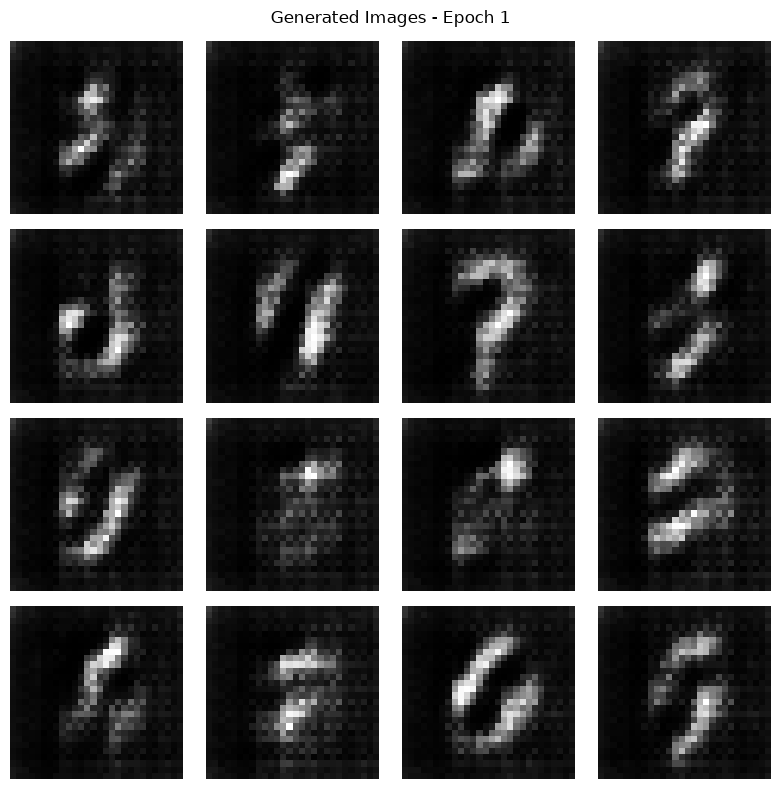

Epoch 02/30 | Generator Loss: 0.7474 | Discriminator Loss: 1.2944
Epoch 03/30 | Generator Loss: 0.7504 | Discriminator Loss: 1.3212
Epoch 04/30 | Generator Loss: 0.7484 | Discriminator Loss: 1.3314
Epoch 05/30 | Generator Loss: 0.7665 | Discriminator Loss: 1.3186


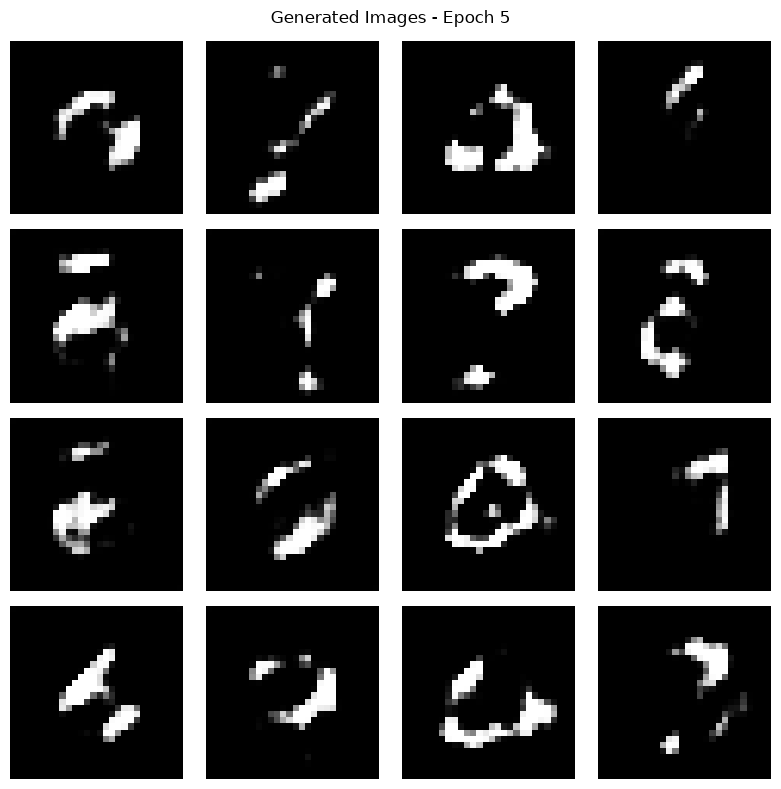

Epoch 06/30 | Generator Loss: 0.7763 | Discriminator Loss: 1.3030
Epoch 07/30 | Generator Loss: 0.7952 | Discriminator Loss: 1.2854
Epoch 08/30 | Generator Loss: 0.8025 | Discriminator Loss: 1.2894
Epoch 09/30 | Generator Loss: 0.7906 | Discriminator Loss: 1.3081
Epoch 10/30 | Generator Loss: 0.7765 | Discriminator Loss: 1.3230


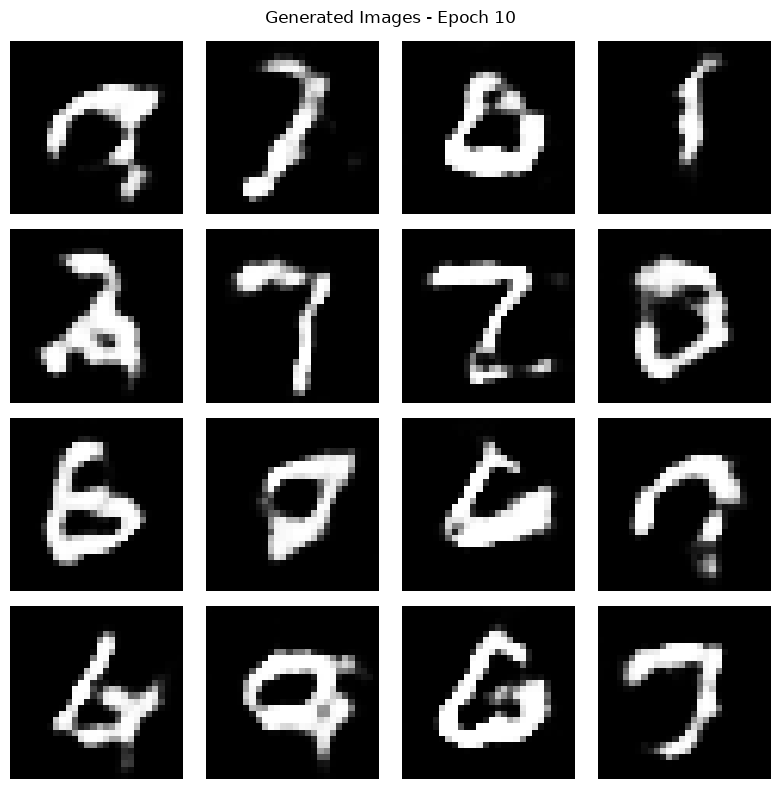

Epoch 11/30 | Generator Loss: 0.7543 | Discriminator Loss: 1.3388
Epoch 12/30 | Generator Loss: 0.7595 | Discriminator Loss: 1.3385
Epoch 13/30 | Generator Loss: 0.7636 | Discriminator Loss: 1.3331
Epoch 14/30 | Generator Loss: 0.7574 | Discriminator Loss: 1.3382
Epoch 15/30 | Generator Loss: 0.7483 | Discriminator Loss: 1.3450


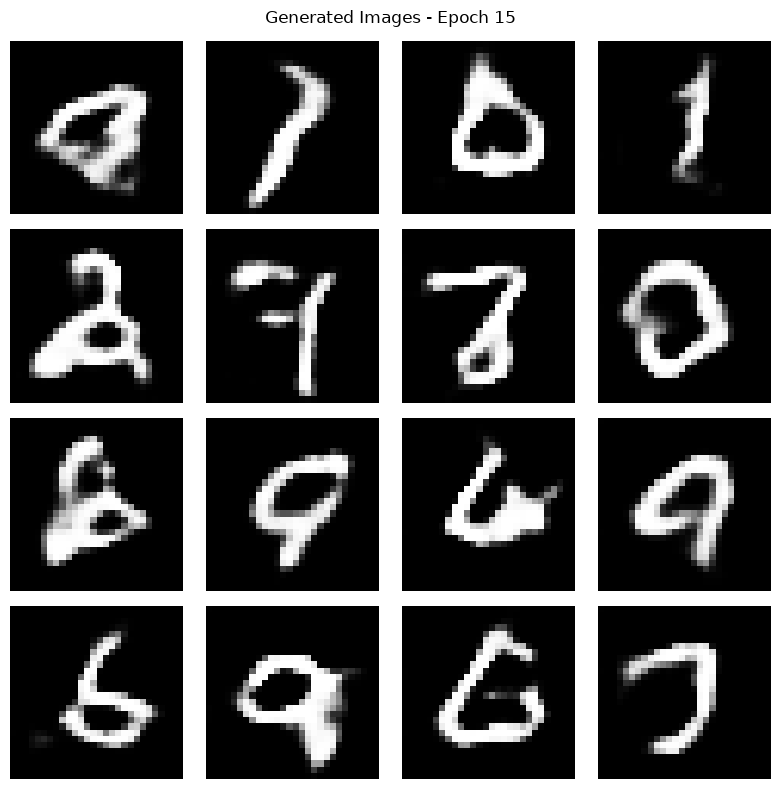

Epoch 16/30 | Generator Loss: 0.7586 | Discriminator Loss: 1.3405
Epoch 17/30 | Generator Loss: 0.7507 | Discriminator Loss: 1.3406
Epoch 18/30 | Generator Loss: 0.7567 | Discriminator Loss: 1.3392
Epoch 19/30 | Generator Loss: 0.7611 | Discriminator Loss: 1.3342
Epoch 20/30 | Generator Loss: 0.7571 | Discriminator Loss: 1.3337


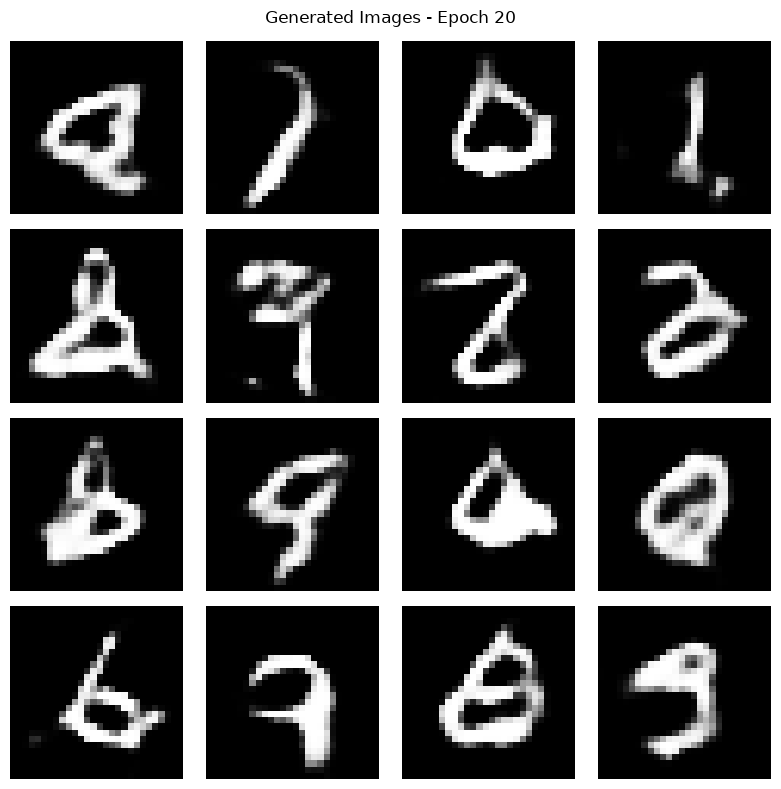

Epoch 21/30 | Generator Loss: 0.7481 | Discriminator Loss: 1.3378
Epoch 22/30 | Generator Loss: 0.7601 | Discriminator Loss: 1.3328
Epoch 23/30 | Generator Loss: 0.7877 | Discriminator Loss: 1.3138
Epoch 24/30 | Generator Loss: 0.7547 | Discriminator Loss: 1.3323
Epoch 25/30 | Generator Loss: 0.7562 | Discriminator Loss: 1.3332


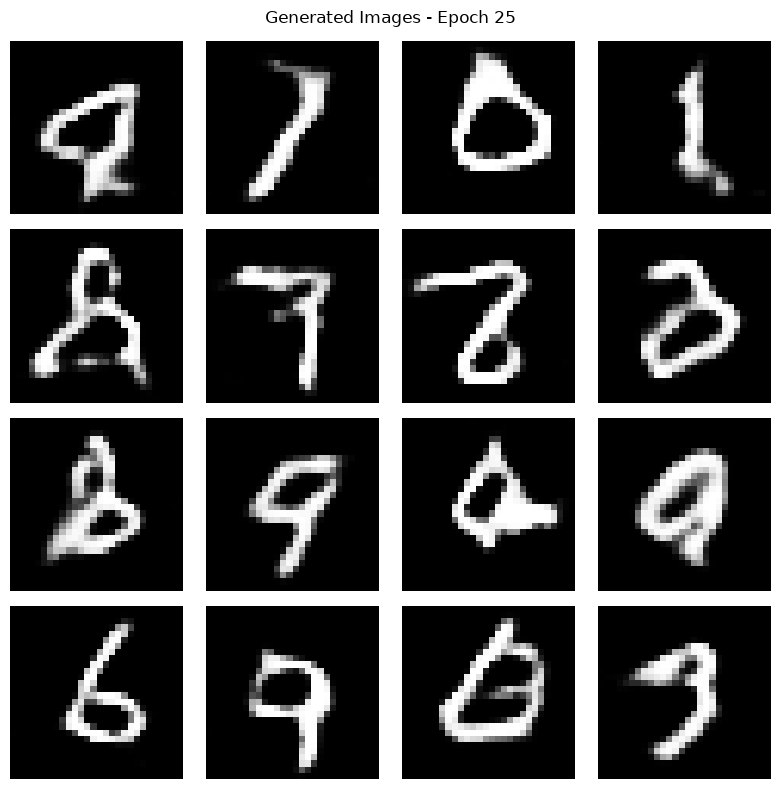

Epoch 26/30 | Generator Loss: 0.7744 | Discriminator Loss: 1.3256
Epoch 27/30 | Generator Loss: 0.7707 | Discriminator Loss: 1.3240
Epoch 28/30 | Generator Loss: 0.7616 | Discriminator Loss: 1.3303
Epoch 29/30 | Generator Loss: 0.7735 | Discriminator Loss: 1.3258
Epoch 30/30 | Generator Loss: 0.7779 | Discriminator Loss: 1.3199


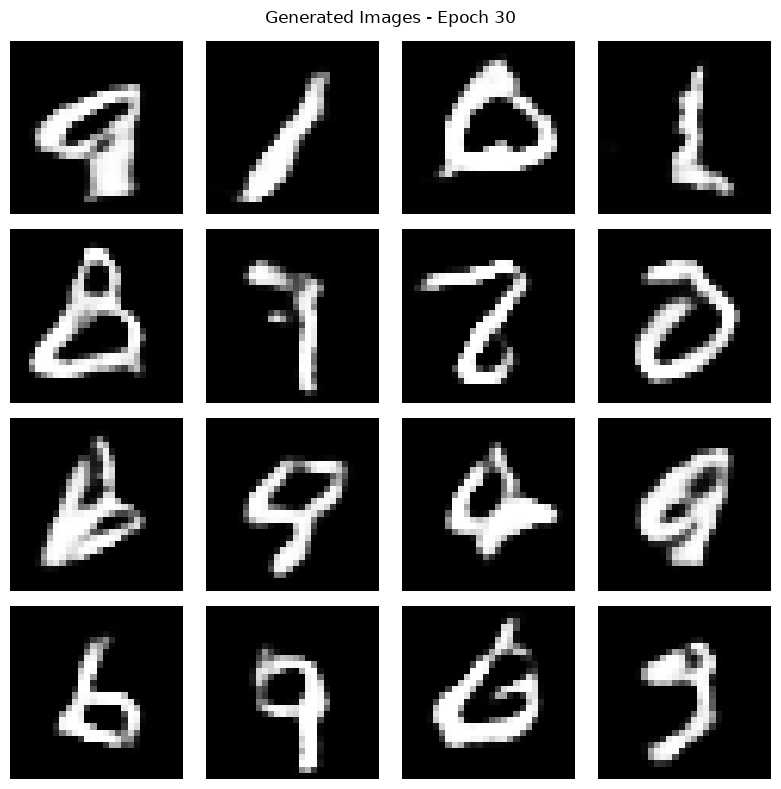

In [ ]:
# Student Roll No: 24BAD407
# GAN training loop

def train(dataset, epochs):

    for epoch in range(1, epochs + 1):

        epoch_gen_losses = []
        epoch_disc_losses = []

        for image_batch in dataset:

            gen_loss, disc_loss = train_step(image_batch)

            epoch_gen_losses.append(float(gen_loss))
            epoch_disc_losses.append(float(disc_loss))

        mean_gen_loss = np.mean(epoch_gen_losses)
        mean_disc_loss = np.mean(epoch_disc_losses)

        generator_losses.append(mean_gen_loss)
        discriminator_losses.append(mean_disc_loss)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Generator Loss: {mean_gen_loss:.4f} | "
            f"Discriminator Loss: {mean_disc_loss:.4f}"
        )

        # Display/save images at important training stages
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            generate_and_save_images(
                generator,
                epoch,
                seed,
                show=True
            )

# Start GAN training
train(train_dataset, EPOCHS)


,Epoch,Generator Loss,Discriminator Loss
25,26,0.774410,1.325574
26,27,0.770714,1.323972
27,28,0.761588,1.330342
28,29,0.773476,1.325830
29,30,0.777857,1.319884


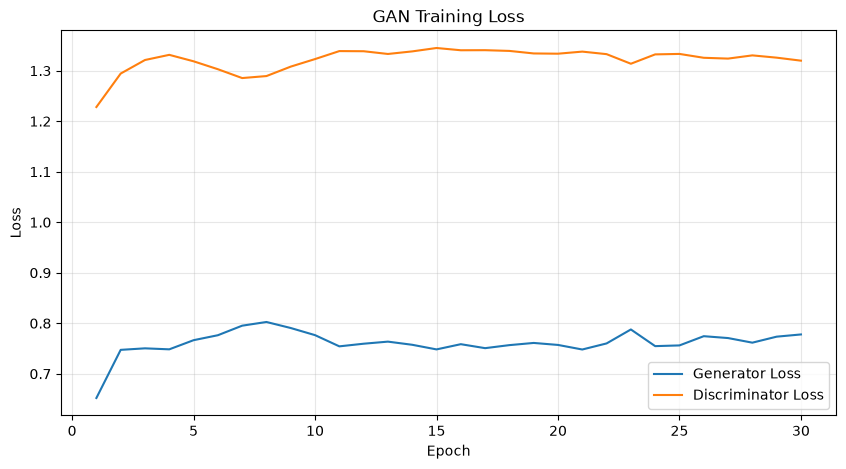

In [ ]:
# Student Roll No: 24BAD407
# Plot Generator and Discriminator losses

loss_df = pd.DataFrame({
    "Epoch": np.arange(1, len(generator_losses) + 1),
    "Generator Loss": generator_losses,
    "Discriminator Loss": discriminator_losses
})

display(loss_df.tail())

plt.figure(figsize=(10, 5))
plt.plot(loss_df["Epoch"], loss_df["Generator Loss"], label="Generator Loss")
plt.plot(loss_df["Epoch"], loss_df["Discriminator Loss"], label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


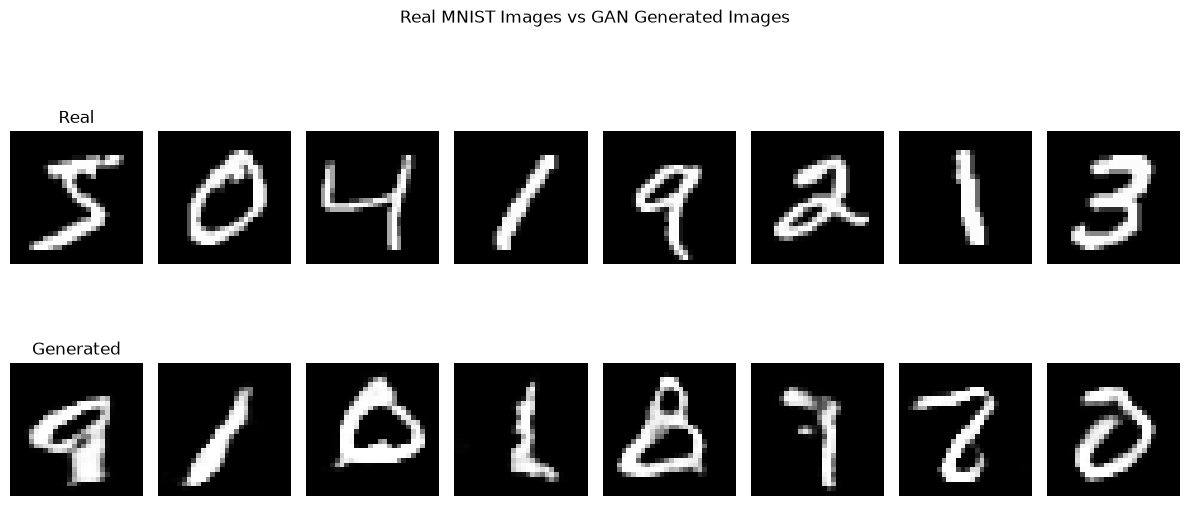

In [ ]:
# Student Roll No: 24BAD407
# Compare real images with generated images

generated_samples = generator(seed, training=False)

plt.figure(figsize=(12, 6))

# First row - Real images
for i in range(8):
    plt.subplot(2, 8, i + 1)
    plt.imshow(x_train[i, :, :, 0], cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Real")

# Second row - Generated images
for i in range(8):
    plt.subplot(2, 8, 8 + i + 1)
    plt.imshow(generated_samples[i, :, :, 0], cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Generated")

plt.suptitle("Real MNIST Images vs GAN Generated Images")
plt.tight_layout()
plt.show()


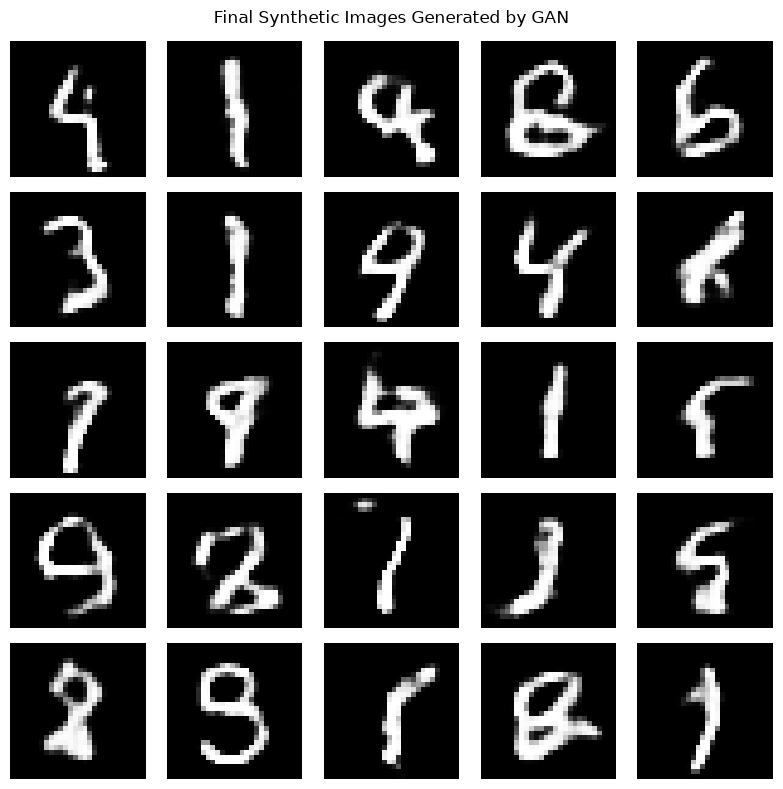

Final generated image grid saved to:
gan_generated_images/final_generated_images.png


In [ ]:
# Student Roll No: 24BAD407
# Generate and save final synthetic images

final_noise = tf.random.normal([25, NOISE_DIM])
final_images = generator(final_noise, training=False)

plt.figure(figsize=(8, 8))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(final_images[i, :, :, 0], cmap="gray")
    plt.axis("off")

plt.suptitle("Final Synthetic Images Generated by GAN")
plt.tight_layout()

final_output_path = os.path.join(
    OUTPUT_DIR,
    "final_generated_images.png"
)

plt.savefig(final_output_path, bbox_inches="tight")
plt.show()

print("Final generated image grid saved to:")
print(final_output_path)


In [ ]:
# Student Roll No: 24BAD407
# Save trained models

generator.save("mnist_gan_generator.keras")
discriminator.save("mnist_gan_discriminator.keras")

print("Generator saved as: mnist_gan_generator.keras")
print("Discriminator saved as: mnist_gan_discriminator.keras")


Generator saved as: mnist_gan_generator.keras
Discriminator saved as: mnist_gan_discriminator.keras


# ANALYSIS OF RESULTS

The generated images can be evaluated by examining their **quality**, **diversity**, and similarity to real MNIST digits.

### 1. Image quality
At the beginning of training, generated outputs appear as random noise. As training continues, digit-like shapes begin to emerge.

### 2. Image diversity
A well-trained GAN should generate different kinds of handwritten digits rather than repeatedly producing nearly identical images.

### 3. Generator vs Discriminator
- The **Discriminator** learns to distinguish real MNIST images from generated images.
- The **Generator** learns from the Discriminator's feedback and improves its ability to synthesize realistic images.

### 4. Adversarial learning
Both networks improve through competition. A balanced training process is important because an excessively strong Discriminator may provide weak learning signals to the Generator.

### 5. Loss interpretation
GAN losses do not always decrease smoothly like standard supervised-learning losses. Oscillation is common because the Generator and Discriminator continuously adapt to one another.


# EXPECTED OUTCOME

Students understand the architecture and working of Generative Adversarial Networks and the interaction between the Generator and Discriminator during adversarial training.

The experiment demonstrates how to:

- Preprocess image data.
- Construct Generator and Discriminator neural networks.
- Apply binary cross-entropy loss and Adam optimization.
- Train both networks using adversarial learning.
- Track Generator and Discriminator losses.
- Generate synthetic handwritten-digit images.
- Compare synthetic images with real images.
- Save trained GAN models and generated output images.

## RESULT
A Generative Adversarial Network was implemented using TensorFlow/Keras and trained on the MNIST dataset. The Generator learned to produce synthetic handwritten-digit images, while the Discriminator learned to distinguish real images from generated images. The quality of generated images improved progressively during GAN training.
